Forward Propagation from scr. , general implementation

In [52]:
import numpy as np 
import tensorflow as tf
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [41]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return X, Y.reshape(-1,1)

X, Y = load_coffee_data()

In [42]:
X.shape

(200, 2)

In [43]:
def sigmoid(z):
    g = 1/(1 + np.exp(-z))
    return g

In [44]:
from tensorflow.keras.layers import Normalization 

norm_l = Normalization(axis=-1)
norm_l.adapt(X)
X_norm = norm_l(X)

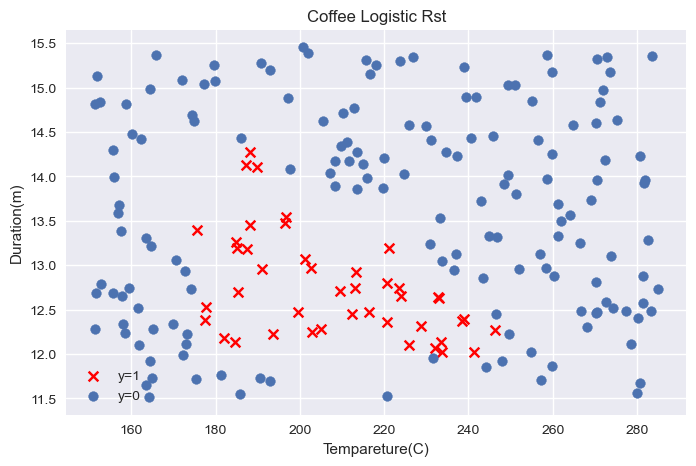

In [55]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
pos = Y==1
neg = Y==0
pos = pos.reshape(-1)
neg = neg.reshape(-1)
ax.scatter(X[pos,0],X[pos,1],marker="x",c="r",label="y=1")
ax.scatter(X[neg,0],X[neg,1],marker="o",label="y=0")
ax.set_title("Coffee Logistic Rst")
ax.set_xlabel("Tempareture(C)")
ax.set_ylabel("Duration(m)")
plt.legend()
plt.show()

In [45]:
def my_dense(a_in, W, b):
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):
        w = W[:,j]
        z_i = np.dot(a_in, w) + b[j]
        a_out[j] = sigmoid(z_i)
    return (a_out)

In [46]:
def my_sequential(x, W1, b1, W2, b2):
    a1 = my_dense(x, W1, b1)
    a2 = my_dense(a1, W2, b2)
    return (a2)

In [47]:
def my_predict(X, W1, b1, W2, b2):
    iter = X.shape[0]
    p = np.zeros((iter,1))
    for i in range(iter):
        p[i,0] = my_sequential(X[i], W1, b1, W2, b2)
    return (p)


In [50]:
X_test = np.array([
    [200,13.9],  
    [200,17]])

X_test_norm = norm_l(X_test)
predict = my_predict(X_test_norm, W1_tmp, b1_tmp, W2_tmp, b2_tmp)

C:\Users\Taiyob Ali\AppData\Local\Temp\ipykernel_11548\569211513.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p[i,0] = my_sequential(X[i], W1, b1, W2, b2)


In [51]:
pred = (predict >= 0.5).astype(int)
print(pred)

[[1]
 [0]]
